In [ ]:
# Dependencies are managed by pyproject.toml / uv.lock for local runs.


In [ ]:
import numpy as np
import pandas as pd
from umap import UMAP
import hdbscan

from sklearn.manifold import trustworthiness

: 

In [ ]:
from pathlib import Path

import yaml

PROJECT_ROOT = Path.cwd()
with open(PROJECT_ROOT / "config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths = config["paths"]
hdbscan_config = config["hdbscan"]
DATA_PATH = PROJECT_ROOT / paths["bertopic_ready"]
EMBEDDING_PATH = PROJECT_ROOT / paths["embeddings"]
UMAP_PATH = PROJECT_ROOT / paths["embeddings_umap"]
LABELS_PATH = PROJECT_ROOT / paths["cluster_labels"]

In [4]:
df = pd.read_csv(DATA_PATH)

embeddings = np.load(EMBEDDING_PATH)


In [14]:
embeddings_umap = np.load(UMAP_PATH)
print(embeddings_umap.shape)


(35993, 5)


In [15]:
# -----------------------------
# Sweep min_cluster_size and min_samples
# -----------------------------
results = []

for min_cluster_size in hdbscan_config["tuning"]["min_cluster_size"]:
    for min_samples in hdbscan_config["tuning"]["min_samples"]:

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric=hdbscan_config["tuning"]["metric"],
            cluster_selection_method=hdbscan_config["tuning"]["cluster_selection_method"],
            gen_min_span_tree=hdbscan_config["tuning"]["gen_min_span_tree"]
        )

        labels = clusterer.fit_predict(embeddings_umap)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = np.mean(labels == -1)
        dbcv = clusterer.relative_validity_

        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "dbcv": dbcv,
        })

        print(f"mcs={min_cluster_size}, ms={min_samples} -> "
              f"clusters={n_clusters}, noise={noise_ratio:.3f}, dbcv={dbcv:.3f}")

results_df = pd.DataFrame(results).sort_values("dbcv", ascending=False).reset_index(drop=True)
print(results_df)

mcs=10, ms=5 -> clusters=766, noise=0.300, dbcv=0.325
mcs=10, ms=10 -> clusters=617, noise=0.307, dbcv=0.314
mcs=10, ms=15 -> clusters=462, noise=0.328, dbcv=0.306
mcs=15, ms=5 -> clusters=536, noise=0.283, dbcv=0.329
mcs=15, ms=10 -> clusters=495, noise=0.309, dbcv=0.322
mcs=15, ms=15 -> clusters=435, noise=0.324, dbcv=0.323
mcs=25, ms=5 -> clusters=322, noise=0.304, dbcv=0.327
mcs=25, ms=10 -> clusters=311, noise=0.336, dbcv=0.331
mcs=25, ms=15 -> clusters=300, noise=0.337, dbcv=0.307
mcs=40, ms=5 -> clusters=213, noise=0.321, dbcv=0.344
mcs=40, ms=10 -> clusters=208, noise=0.352, dbcv=0.288
mcs=40, ms=15 -> clusters=200, noise=0.332, dbcv=0.264
mcs=60, ms=5 -> clusters=137, noise=0.337, dbcv=0.296
mcs=60, ms=10 -> clusters=129, noise=0.342, dbcv=0.295
mcs=60, ms=15 -> clusters=126, noise=0.355, dbcv=0.237
    min_cluster_size  min_samples  n_clusters  noise_ratio      dbcv
0                 40            5         213     0.320757  0.343974
1                 25           10         

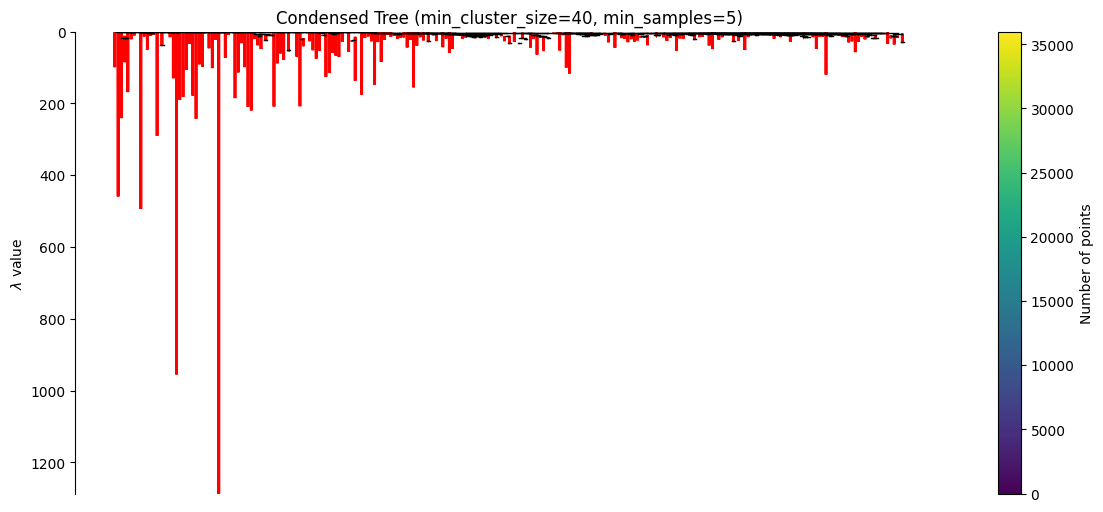

In [17]:
import matplotlib.pyplot as plt

# Refit with your chosen best config to inspect the tree
best = results_df.iloc[0]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=int(best.min_cluster_size),
    min_samples=int(best.min_samples),
    metric=hdbscan_config["final"]["metric"],
    cluster_selection_method=hdbscan_config["final"]["cluster_selection_method"],
    gen_min_span_tree=hdbscan_config["final"]["gen_min_span_tree"]
)
labels = clusterer.fit_predict(embeddings_umap)

# Condensed tree plot: shows clusters splitting/dying as density threshold changes
plt.figure(figsize=(14, 6))
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=None)
plt.title(f"Condensed Tree (min_cluster_size={int(best.min_cluster_size)}, min_samples={int(best.min_samples)})")
plt.show()

In [18]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_ratio = np.mean(labels == -1)

print(f"Final: {n_clusters} clusters, {noise_ratio:.1%} noise")
print(pd.Series(labels).value_counts().head(20))

np.save(LABELS_PATH, labels)


Final: 213 clusters, 32.1% noise
-1      11545
 116     1314
 207      967
 91       772
 135      703
 112      478
 176      432
 134      426
 58       371
 177      313
 37       308
 179      302
 46       268
 165      261
 146      259
 186      249
 156      237
 100      221
 67       218
 195      209
Name: count, dtype: int64


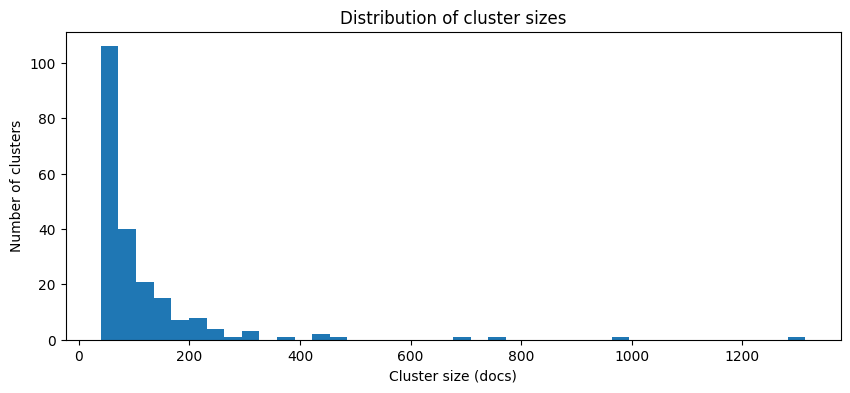

Smallest cluster: 40, Largest cluster: 1314, Median: 72.0


In [19]:
sizes = pd.Series(labels).value_counts()
sizes = sizes[sizes.index != -1]  # drop noise

plt.figure(figsize=(10, 4))
plt.hist(sizes, bins=40)
plt.xlabel("Cluster size (docs)")
plt.ylabel("Number of clusters")
plt.title("Distribution of cluster sizes")
plt.show()

print(f"Smallest cluster: {sizes.min()}, Largest cluster: {sizes.max()}, Median: {sizes.median()}")